0    900    900.3670051043612
1    883    882.8615702963975
10    730    743.4459778267799
2    866    864.9758373138259
3    849    847.7957858479577
4    832    830.512784041971
5    815    813.6081357352764
6    798    796.8734931743778
7    781    780.2526166573507
8    764    763.9708179240575
9    747    749.9255375188601
-1    917    916.9340081397692
-2    934    932.3128830871851
-3    951    950.178745754072
-4    968    965.6355972152284
-5    985    979.938423974748


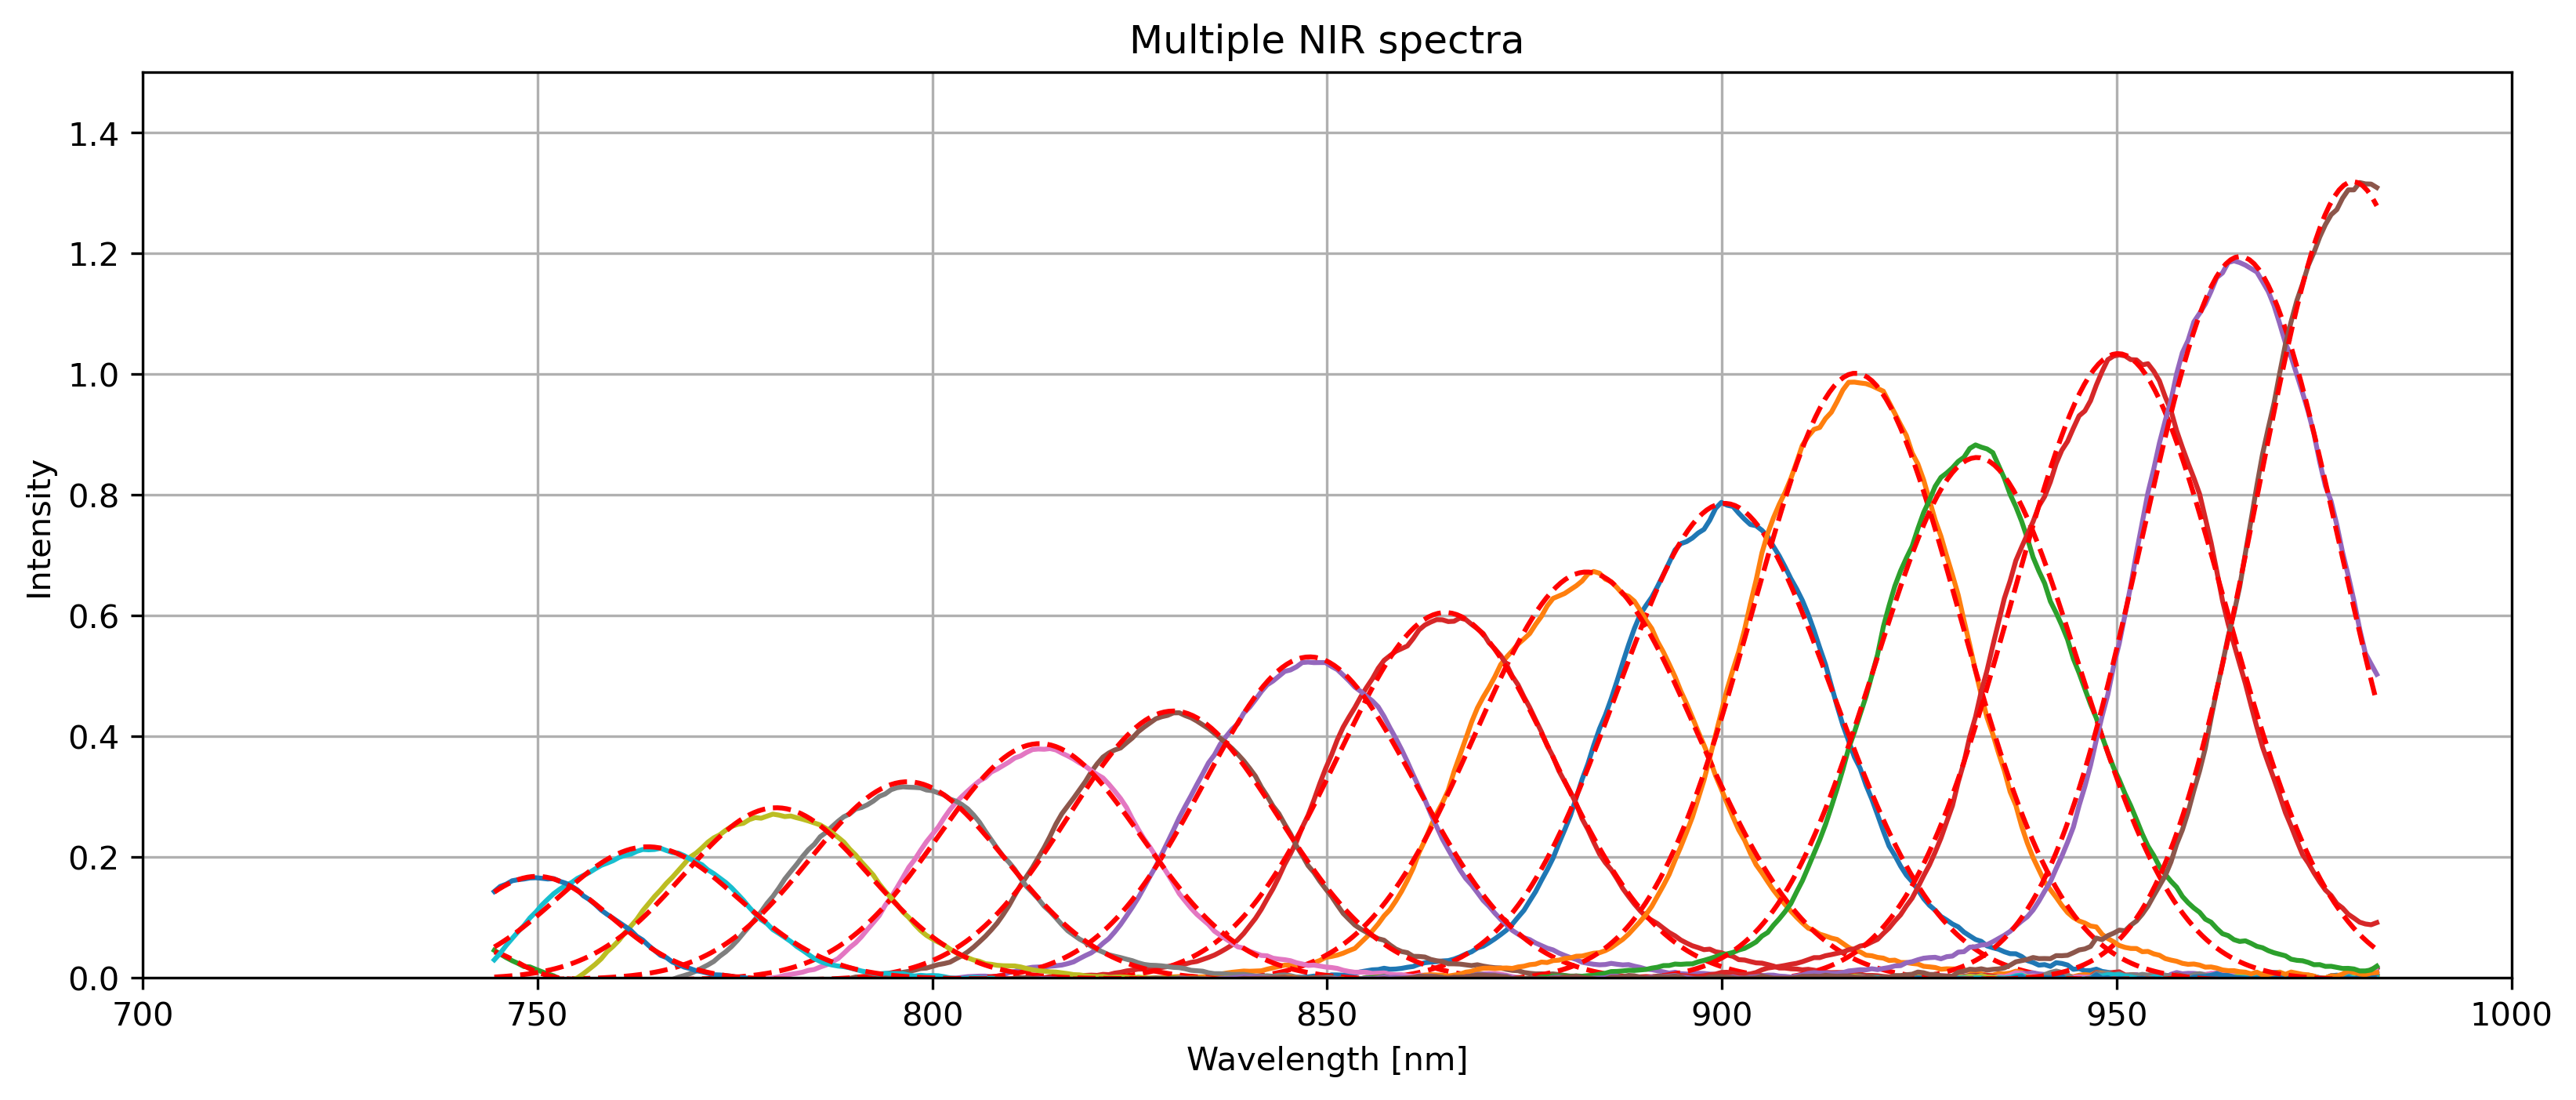

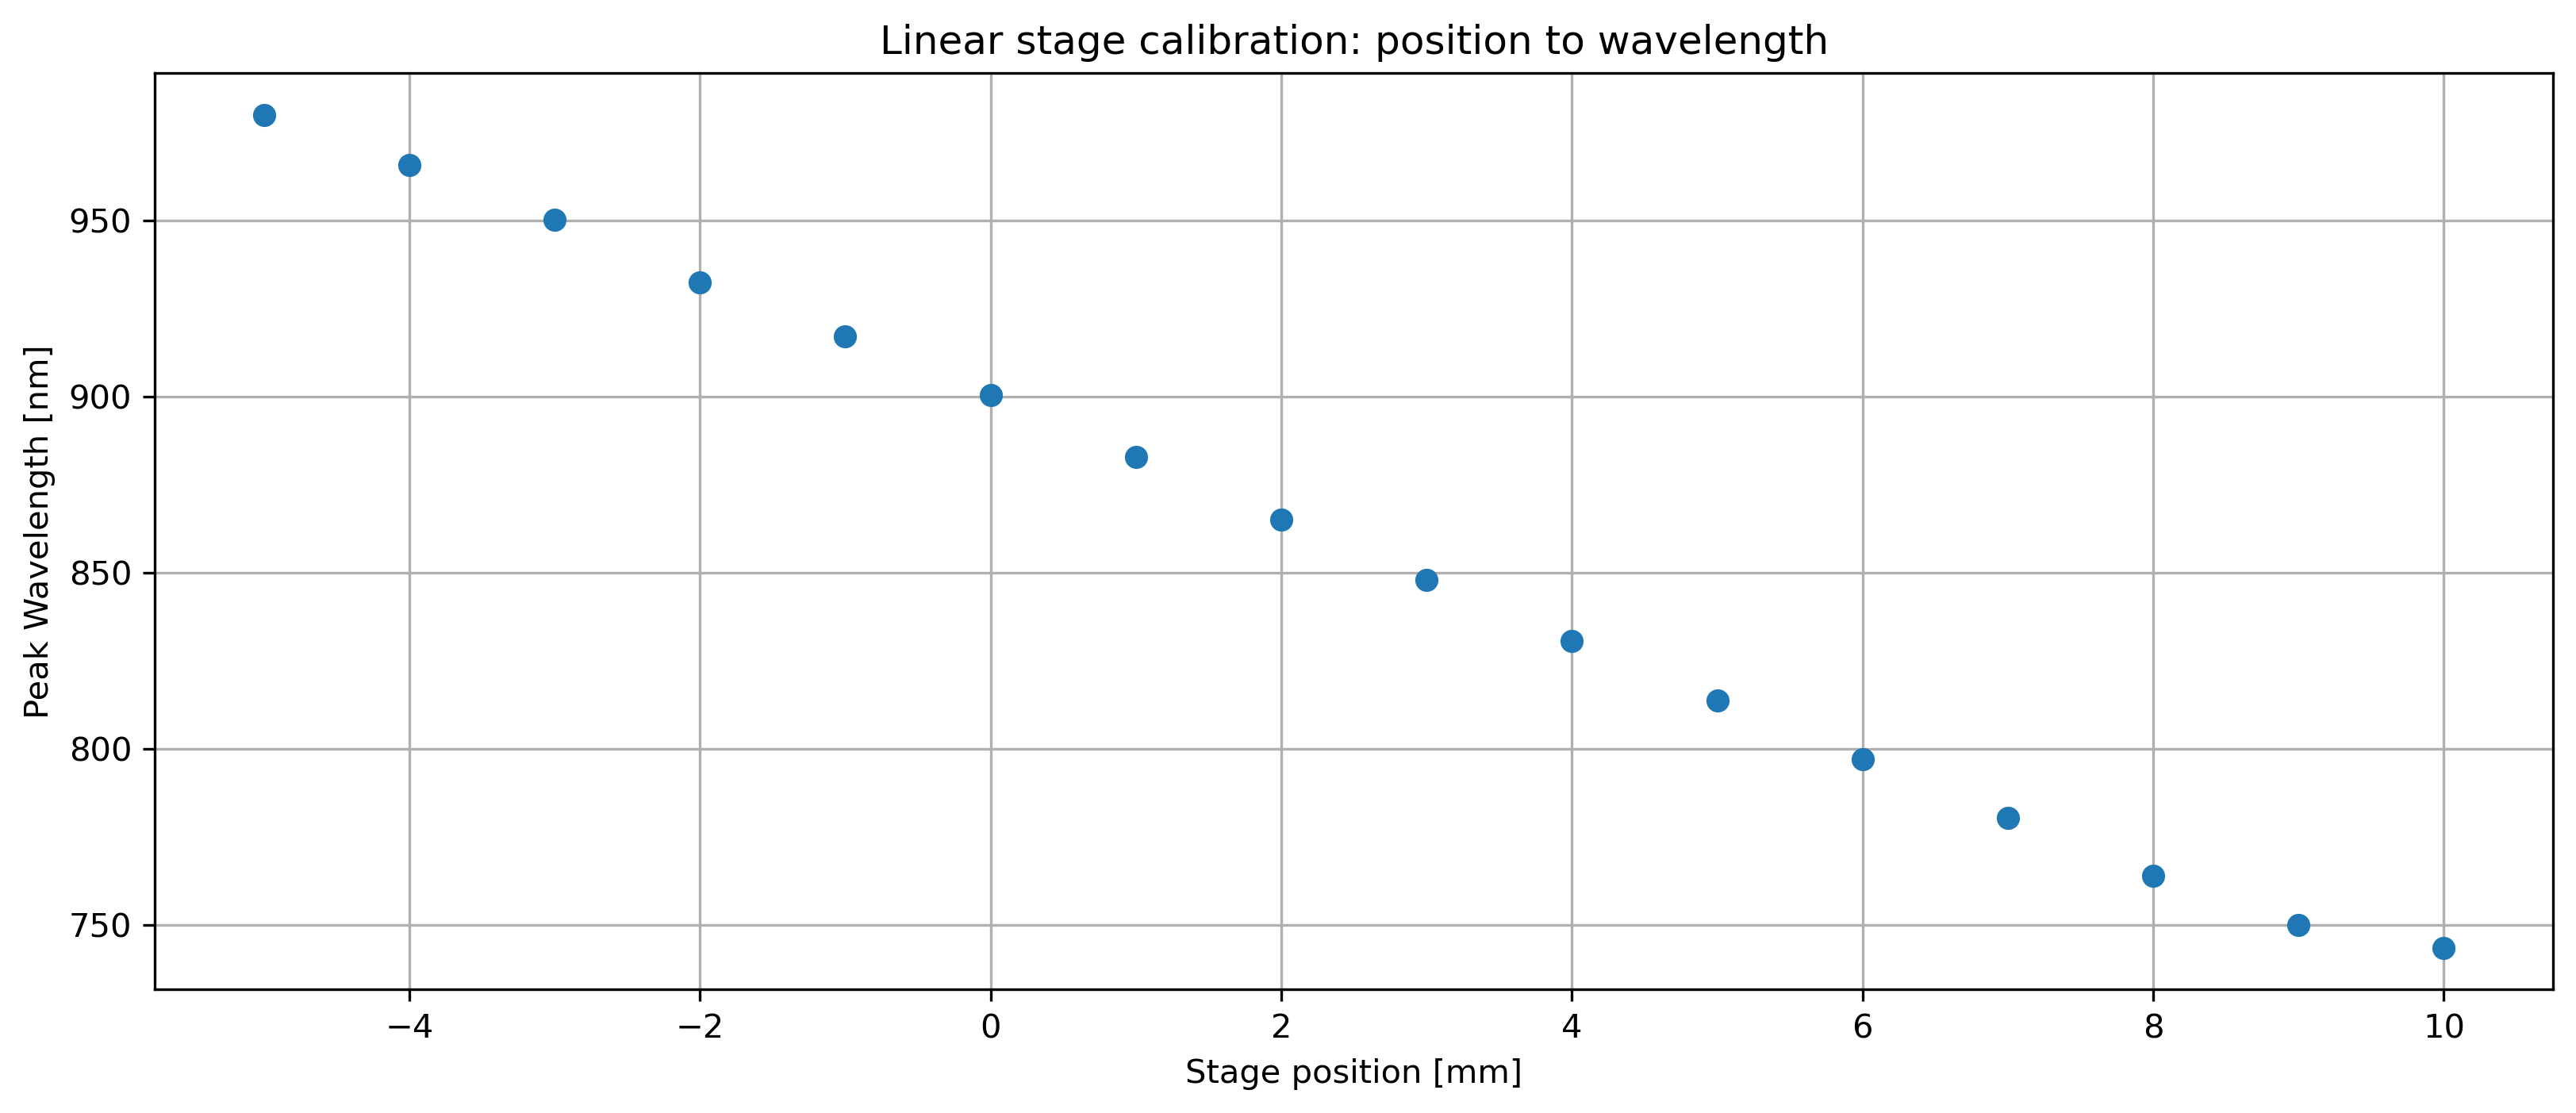

In [ ]:
import glob
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import re

def gaussian(x, A, x0, sigma, offset):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset


# Path to your file pattern
data_mappe = f"/home/daniel/Desktop/Uni/6 Semester/Bachelorprojekt/bachelorprojekt/data/raw/ayat_aleena/*.txt"

file_list = sorted(glob.glob(data_mappe))


plt.figure(figsize=(13, 5), dpi=300)

offset = []
wavelength =[]

for fname in file_list:        # loop through actual files
    with open(fname, "r") as f:
        lines = f.readlines()

    dataX = []
    dataY = []

    for line in lines[717:1041]:     # skip first 17 lines
        parts = line.strip().split("\t")
        valueX = float(parts[0].replace(",", "."))
        valueY = float(parts[1].replace(",", "."))
        dataX.append(valueX)
        dataY.append(valueY)

    # Convert to numpy arrays
    x = np.array(dataX)
    y = np.array(dataY)

    position=int(re.findall(r"\d+", fname[-7:])[0])
    if fname[-6:-5]=="_":
        position=-position

    A_guess = 1.5 - 0
    x0_guess = 900-position*17
    sigma_guess = (980 - 750) / 10
    offset_guess = 0

    p0 = [A_guess, x0_guess, sigma_guess, offset_guess]

    # Fit
    popt, pcov = curve_fit(gaussian, x, y, p0=p0)
    A_fit, x0_fit, sigma_fit, offset_fit = popt
    plt.plot(dataX, dataY, label=fname)   # plot each file

    x_fit = np.linspace(min(x), max(x), 400)
    y_fit = gaussian(x_fit, *popt)
    plt.plot(x_fit, y_fit, 'r--', label='Gaussian fit')

    print(position, "  ", x0_guess, "  ", popt[1])
    offset.append(position)
    wavelength.append(popt[1])

plt.xlim(700, 1000)     # example: wavelength range in nm
plt.ylim(0, 1.5)         # example: intensity range
plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity")
plt.title("Multiple NIR spectra")
plt.grid()
plt.show()

plt.figure(figsize=(13, 5), dpi=300)
plt.plot(offset, wavelength, label=fname, marker='o', linestyle='none')   # plot each file
plt.xlabel("Stage position [mm]")
plt.ylabel("Peak Wavelength [nm]")
plt.title("Linear stage calibration: position to wavelength")
plt.grid()
plt.show()


# Beregning af stage position for at få specifikke bølgelængder

In [ ]:
import numpy as np

positions = np.array([-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9])
wavelengths = np.array([
    979.938423974748,
    965.6355972152284,
    950.178745754072,
    932.3128830871851,
    916.9340081397692,
    900.3670051043612,
    882.8615702963975,
    864.9758373138259,
    847.7957858479577,
    830.512784041971,
    813.6081357352764,
    796.8734931743778,
    780.2526166573507,
    763.9708179240575,
    749.9255375188601
])

a, b = np.polyfit(positions, wavelengths, 1)

print(f"Lambda = {a:.4f} * x + {b:.4f}")

Lambda = -16.7722 * x + 898.6206


$$
\lambda = -16.7722 \cdot x + 898.6206
$$
Isolerer $x$:

$$
x = \frac{\lambda - 898.6206}{-16.7722}
$$

In [ ]:
def stage_from_wavelength(lam):
    return (lam - b) / a

for lam in [800, 810, 820, 930, 940, 950]:
    print(f"{lam} nm -> {stage_from_wavelength(lam):.3f} mm")

800 nm -> 5.880 mm
810 nm -> 5.284 mm
820 nm -> 4.688 mm
930 nm -> -1.871 mm
940 nm -> -2.467 mm
950 nm -> -3.063 mm
